<a href="https://colab.research.google.com/github/takuma1229/nlp100/blob/main/chapter6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 第六章　機械学習

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 50

In [2]:
columns = "TITLE\tURL\tPUBLISHER\tCATEGORY\tSTORY\tHOSTNAME\tTIMESTAMP".split("\t")

In [3]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/nlp100/NewsAggregatorDataset/newsCorpora.csv", names=columns, sep="\t")
df

,TITLE,URL,PUBLISHER,CATEGORY,STORY,HOSTNAME,TIMESTAMP
1,"Fed official says weak data caused by weather,...",http://www.latimes.com/business/money/la-fi-mo...,Los Angeles Times,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.latimes.com,1394470370698
2,Fed's Charles Plosser sees high bar for change...,http://www.livemint.com/Politics/H2EvwJSK2VE6O...,Livemint,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.livemint.com,1394470371207
3,US open: Stocks fall after Fed official hints ...,http://www.ifamagazine.com/news/us-open-stocks...,IFA Magazine,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.ifamagazine.com,1394470371550
4,"Fed risks falling 'behind the curve', Charles ...",http://www.ifamagazine.com/news/fed-risks-fall...,IFA Magazine,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.ifamagazine.com,1394470371793
5,Fed's Plosser: Nasty Weather Has Curbed Job Gr...,http://www.moneynews.com/Economy/federal-reser...,Moneynews,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.moneynews.com,1394470372027
...,...,...,...,...,...,...,...
422933,Surgeons to remove 4-year-old's rib to rebuild...,http://www.cbs3springfield.com/story/26378648/...,WSHM-TV,m,dpcLMoJD69UYMXMxaoEFnWql9YjQM,www.cbs3springfield.com,1409229190251
422934,Boy to have surgery on esophagus after battery...,http://www.wlwt.com/news/boy-to-have-surgery-o...,WLWT Cincinnati,m,dpcLMoJD69UYMXMxaoEFnWql9YjQM,www.wlwt.com,1409229190508
422935,Child who swallowed battery to have reconstruc...,http://www.newsnet5.com/news/local-news/child-...,NewsNet5.com,m,dpcLMoJD69UYMXMxaoEFnWql9YjQM,www.newsnet5.com,1409229190771
422936,Phoenix boy undergoes surgery to repair throat...,http://www.wfsb.com/story/26368078/phoenix-boy...,WFSB,m,dpcLMoJD69UYMXMxaoEFnWql9YjQM,www.wfsb.com,1409229191071


情報源（publisher）が”Reuters”, “Huffington Post”, “Businessweek”, “Contactmusic.com”, “Daily Mail”の事例（記事）のみを抽出する．

In [4]:
df = df.loc[df['PUBLISHER'].isin(['Reuters', 'Huffington Post', 'Businessweek', 'Contactmusic.com', 'Daily Mail'])]

In [5]:
df

,TITLE,URL,PUBLISHER,CATEGORY,STORY,HOSTNAME,TIMESTAMP
13,Europe reaches crunch point on banking union,http://in.reuters.com/article/2014/03/10/eu-ba...,Reuters,b,dPhGU51DcrolUIMxbRm0InaHGA2XM,in.reuters.com,1394470501755
14,ECB FOCUS-Stronger euro drowns out ECB's messa...,http://in.reuters.com/article/2014/03/10/ecb-p...,Reuters,b,dPhGU51DcrolUIMxbRm0InaHGA2XM,in.reuters.com,1394470501948
20,"Euro Anxieties Wane as Bunds Top Treasuries, S...",http://www.businessweek.com/news/2014-03-10/ge...,Businessweek,b,dPhGU51DcrolUIMxbRm0InaHGA2XM,www.businessweek.com,1394470503148
21,Noyer Says Strong Euro Creates Unwarranted Eco...,http://www.businessweek.com/news/2014-03-10/no...,Businessweek,b,dPhGU51DcrolUIMxbRm0InaHGA2XM,www.businessweek.com,1394470503366
30,REFILE-Bad loan triggers key feature in ECB ba...,http://in.reuters.com/article/2014/03/10/euroz...,Reuters,b,dPhGU51DcrolUIMxbRm0InaHGA2XM,in.reuters.com,1394470505070
...,...,...,...,...,...,...,...
422819,UN: Ebola Could Eventually Infect 20000 People,http://www.huffingtonpost.com/2014/08/28/ebola...,Huffington Post,m,dhhnSHVoyA7ENBM3boDX_D_-3PV6M,www.huffingtonpost.com,1409228423333
422820,"Ebola toll tops 1550, continues to accelerate ...",http://in.reuters.com/article/2014/08/28/healt...,Reuters,m,dhhnSHVoyA7ENBM3boDX_D_-3PV6M,in.reuters.com,1409228423827
422821,"UPDATE 1-Ebola toll tops 1550, outbreak accele...",http://in.reuters.com/article/2014/08/28/healt...,Reuters,m,dhhnSHVoyA7ENBM3boDX_D_-3PV6M,in.reuters.com,1409228424525
422828,"Ebola Cases May Surpass 20000, WHO Says in Upd...",http://www.businessweek.com/news/2014-08-28/eb...,Businessweek,m,dhhnSHVoyA7ENBM3boDX_D_-3PV6M,www.businessweek.com,1409228426943


抽出された事例をランダムに並び替える

In [6]:
df = df.sample(frac=1)

抽出された事例の80%を学習データ，残りの10%ずつを検証データと評価データに分割し，それぞれtrain.txt，valid.txt，test.txtというファイル名で保存する．ファイルには，１行に１事例を書き出すこととし，カテゴリ名と記事見出しのタブ区切り形式とせよ（このファイルは後に問題70で再利用する）．

In [7]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, shuffle=False)
val_df, test_df = train_test_split(test_df, test_size=0.5, shuffle=False)

In [8]:
def write_to_txt(file_name, category_list, article_list):
    file_path = "/content/drive/MyDrive/nlp100/NewsAggregatorDataset/" + file_name
    f = open(file_path, mode="w")
    for i in range(len(category_list)):
        f.write(f"{category_list[i]} \t {article_list[i]} \n")
    f.close()

In [9]:
# write_to_txt("train.txt", train_df["CATEGORY"].to_list(), train_df["TITLE"].to_list())
# write_to_txt("test.txt", test_df["CATEGORY"].to_list(), test_df["TITLE"].to_list())
# write_to_txt("val.txt", val_df["CATEGORY"].to_list(), val_df["TITLE"].to_list())


In [10]:
print(len(train_df))
print(len(test_df))
print(len(val_df))


10672
1334
1334


## 51. 特徴量抽出

学習データ，検証データ，評価データから特徴量を抽出し，それぞれtrain.feature.txt，valid.feature.txt，test.feature.txtというファイル名で保存せよ． なお，カテゴリ分類に有用そうな特徴量は各自で自由に設計せよ．記事の見出しを単語列に変換したものが最低限のベースラインとなるであろう．

In [69]:
from sklearn.feature_extraction.text import TfidfVectorizer



def extract_tfidf_feature(title_list):
    vectorizer = TfidfVectorizer()
    import gc 
    gc.collect()
    X = vectorizer.fit_transform(title_list)
    print(vectorizer.get_feature_names())
    return X.toarray()

def extract_tfidf_feature_for_unk(title_list, corpus):
    vectorizer = TfidfVectorizer()
    _ = vectorizer.fit_transform(corpus)
    X = vectorizer.transform(title_list)
    return X.toarray()

def output_feature_to_txt(title_list):
    tfidf = extract_tfidf_feature(title_list)
    file_path = "/content/drive/MyDrive/nlp100/NewsAggregatorDataset/" 
    f = open(file_path + "train_feature.txt", mode="w")
    for scores in tfidf[:len(train_df)]:
        f.write("\t".join(map(str, scores)))
        f.write("\n")
    f.close()
    f = open(file_path + "test_feature.txt", mode="w")
    for scores in tfidf[len(train_df):len(train_df)+len(test_df)]:
        f.write("\t".join(map(str, scores)))
        f.write("\n")
    f.close()
    f = open(file_path + "val_feature.txt", mode="w")
    for scores in tfidf[len(train_df)+len(test_df):]:
        f.write("\t".join(map(str, scores)))
        f.write("\n")
    f.close()



In [70]:
extract_tfidf_feature(df["TITLE"].to_list())



/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


['00', '05', '07', '08', '09', '0ff', '0ut', '10', '100', '1000', '10000', '100000', '100k', '100th', '101', '103', '104', '106', '107', '108', '10k', '10m', '10million', '10th', '11', '110', '1100', '111', '113', '114', '115', '1150', '116', '117', '118', '11m', '12', '120', '1201178058', '121', '1270', '129', '13', '1300', '131', '1399983366398', '1399983366584', '1399983366926', '1399983367118', '1399983367406', '1399983367691', '1399985294553', '1399985294870', '1399985295162', '1399985295432', '13th', '14', '142136', '148', '148948', '149002', '14lb', '14m', '14th', '15', '150', '1500', '150m', '1550', '156000', '15lbs', '15m', '15th', '16', '16000', '16k', '16m', '17', '17000', '172', '175', '17500', '178', '179', '18', '18000', '186f', '19', '1900', '19000', '1914', '1918', '1950s', '1956', '1964', '1978', '1979', '1980s', '1981', '1983', '1987', '1990', '1990s', '1995', '1996', '1997', '1998', '1999', '19m', '19th', '1bn', '1d', '1m', '1q', '1st', '20', '200', '2000', '20000', 

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [12]:
# output_feature_to_txt(df["TITLE"].to_list())

In [13]:
#tfidfは未知語に対する問題がある...

## 52. 学習
51で構築した学習データを用いて，ロジスティック回帰モデルを学習せよ．

In [14]:
feature_list = list(extract_tfidf_feature(df["TITLE"].to_list()))
train_df["feature"] = feature_list[:len(train_df)]
test_df["feature"] = feature_list[len(train_df):len(train_df)+len(test_df)]
val_df["feature"] = feature_list[len(train_df)+len(test_df):]

In [15]:
train_df

,TITLE,URL,PUBLISHER,CATEGORY,STORY,HOSTNAME,TIMESTAMP,feature
103501,Khloé Kardashian - Khloé Kardashian ignoring L...,http://www.contactmusic.com/story/khlo-kardash...,Contactmusic.com,e,diZrKDjXzDYF7ZMZLEaUdwN1E52IM,www.contactmusic.com,1397298189826,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
183247,Danica McKellar is eliminated from Dancing Wit...,http://www.dailymail.co.uk/tvshowbiz/article-2...,Daily Mail,e,d_hkNefz8uam2tMyhuI0QgziXPDCM,www.dailymail.co.uk,1399384795957,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
267092,Airlines debate costs of aircraft tracking aft...,http://www.reuters.com/article/2014/06/03/us-a...,Reuters,b,dvOCJcFbRib3qfMf-i8Phns5Do-gM,www.reuters.com,1401801007726,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
364498,European Factors to Watch-Shares set to consol...,http://in.reuters.com/article/2014/07/07/marke...,Reuters,b,dijHYgYRq4ls0AMDzGAi9IgDtxTxM,in.reuters.com,1404754631766,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
371198,UPDATE 2-Amazon courts Hachette authors by pro...,http://www.reuters.com/article/2014/07/08/amaz...,Reuters,b,djB9LBsrA_0TyHM5hCZ0Jo3ZOqBnM,www.reuters.com,1404893961261,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...,...,...,...,...,...
219780,Deutsche Bank investment banking revenues may ...,http://in.reuters.com/article/2014/05/19/deuts...,Reuters,b,d00cInYMRHLlE8MjJH5RWuRePdmMM,in.reuters.com,1400509911956,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
318273,This means war! Google throws the latest punch...,http://www.dailymail.co.uk/sciencetech/article...,Daily Mail,t,dhUefRghWVoxEWM5hK6CWiSBOYw7M,www.dailymail.co.uk,1403783614427,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
104184,"Coachella Tickets Among the Hottest, Priciest ...",http://www.huffingtonpost.com/jesse-lawrence/c...,Huffington Post,e,dPEFe3CUUOuV97Mp-uMBvJB9zMuHM,www.huffingtonpost.com,1397300298236,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
192438,TABLE-Toyota Motor -2013/14 group results (SEC),http://in.reuters.com/article/2014/05/08/idINX...,Reuters,b,dK_8AM8fOxT0pvMjcLiE6-fiodKSM,in.reuters.com,1399560523893,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [16]:
from sklearn.linear_model import LogisticRegression

#b = business, t = science and technology, e = entertainment, m = health
X_train = train_df["feature"].to_list()
train_df["CATEGORY"].map({"b": 0, "t": 1, "e": 2, "m": 3})
y_train = train_df["CATEGORY"].map({"b": 0, "t": 1, "e": 2, "m": 3}).to_list()

print(X_train)
print("===")
print(y_train)

lr = LogisticRegression(max_iter=10000)
lr.fit(X_train, y_train)

[array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 0., 0., ..., 0., 0., 0.]), array([0., 

LogisticRegression(max_iter=10000)

## 53. 予測
52で学習したロジスティック回帰モデルを用い，与えられた記事見出しからカテゴリとその予測確率を計算するプログラムを実装せよ．

In [17]:
text = "i think therefore i am! hdufhauiai"
feature = extract_tfidf_feature_for_unk([text], df["TITLE"].to_list())
lr.predict(feature)

array([2])

## 54. 正解率の計測
52で学習したロジスティック回帰モデルの正解率を，学習データおよび評価データ上で計測せよ．

In [21]:
#まずはTrainデータについて正解率を計測
from sklearn.metrics import classification_report
pred_train = lr.predict(X_train)
print(classification_report(y_train, pred_train))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96      4488
           1       0.96      0.78      0.86      1213
           2       0.93      1.00      0.96      4233
           3       0.99      0.72      0.84       738

    accuracy                           0.95     10672
   macro avg       0.96      0.87      0.91     10672
weighted avg       0.95      0.95      0.94     10672



In [24]:
#テストデータについても正解率を計測
#b = business, t = science and technology, e = entertainment, m = health
X_test = test_df["feature"].to_list()
test_df["CATEGORY"].map({"b": 0, "t": 1, "e": 2, "m": 3})
y_test = test_df["CATEGORY"].map({"b": 0, "t": 1, "e": 2, "m": 3}).to_list()

pred_test = lr.predict(X_test)
print(classification_report(y_test, pred_test))

#過学習っぽい

              precision    recall  f1-score   support

           0       0.44      0.45      0.45       577
           1       0.15      0.09      0.11       152
           2       0.39      0.46      0.42       512
           3       0.02      0.01      0.01        93

    accuracy                           0.38      1334
   macro avg       0.25      0.25      0.25      1334
weighted avg       0.36      0.38      0.37      1334



## 55. 混同行列の作成
52で学習したロジスティック回帰モデルの混同行列（confusion matrix）を，学習データおよび評価データ上で作成せよ

他クラス分類におけるconfusion matrixの説明図
（https://atmarkit.itmedia.co.jp/ait/articles/2208/17/news039.html より引用）

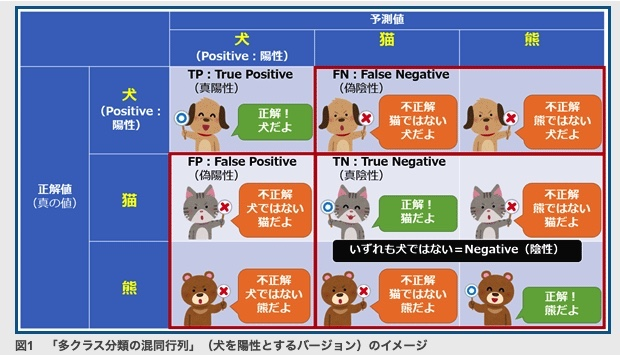

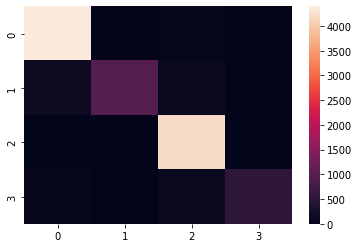

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns 
import matplotlib.pyplot as plt

#まず学習データ
cm_train = confusion_matrix(y_train, pred_train)
sns.heatmap(cm_train)

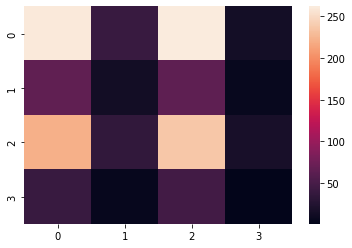

In [30]:
#次にテストデータ
cm_test = confusion_matrix(y_test, pred_test)
sns.heatmap(cm_test)

## 56. 適合率，再現率，F1スコアの計測
52で学習したロジスティック回帰モデルの適合率，再現率，F1スコアを，評価データ上で計測せよ．カテゴリごとに適合率，再現率，F1スコアを求め，カテゴリごとの性能をマイクロ平均（micro-average）とマクロ平均（macro-average）で統合せよ

micro-average, macro-average, weighted-averageについては以下の記事を要参照
https://www.haya-programming.com/entry/2018/03/14/112454#%E3%83%9E%E3%82%AF%E3%83%AD%E5%B9%B3%E5%9D%87

1. マクロ平均
  - クラスごとのデータ件数の比率を考慮しない
  - クラスごとの件数がbalancedならばこれを使っても問題ないパターンが多い
  - 「件数に関わらず、どのクラスにも同じ価値がある」とみなす
2. マイクロ平均
  - クラスごとのデータ件数の比率を考慮する
  - 件数が多いクラスの評価ほど全体の評価に強く影響する

In [38]:
#macro-averageについてはclassification_reportで既に算出している。
#micro-averageを新たに算出
from sklearn.metrics import precision_score, recall_score, f1_score

#まずはtrainから
print(("micro precision : {}").format(precision_score(y_train, pred_train, average="micro")))
print(("micro recall : {}").format(recall_score(y_train, pred_train, average="micro")))
print(("micro f1_score : {}").format(f1_score(y_train, pred_train, average="micro")))


micro precision : 0.9457458770614693
micro recall : 0.9457458770614693
micro f1_score : 0.9457458770614693


In [40]:
#次にtest
print(("micro precision : {}").format(precision_score(y_test, pred_test, average="micro")))
print(("micro recall : {}").format(recall_score(y_test, pred_test, average="micro")))
print(("micro f1_score : {}").format(f1_score(y_test, pred_test, average="micro")))

micro precision : 0.383808095952024
micro recall : 0.383808095952024
micro f1_score : 0.383808095952024


In [41]:
#micro-averageは同一スコアになってよいっぽいが、なぜそうなるのかがよくわかっていない......

## 57. 特徴量の重みの確認
52で学習したロジスティック回帰モデルの中で，重みの高い特徴量トップ10と，重みの低い特徴量トップ10を確認せよ．

-  np.argsort[n] は「n番目（実際はindexは0始まりなのでn+1だが）に小さい値のindex」を示していることが理解のポイント。

In [56]:
#重みはcoef_を見ることでわかる
#shapeは(n_classes, n_features)

import numpy as np

# print(lr.coef_[0])
# print(type(lr.coef_[0][0]))
# print(len(lr.coef_[0]))

weights = lr.coef_
weight_score_list = []

for feature in range(len(lr.coef_[0])):
    weight_sum = 0
    for cls in range(4):
        weight_sum += abs(weights[cls][feature])
    weight_score_list.append(weight_sum/4)

# print(weight_score_list)
argsorted = np.argsort(weight_score_list)

smallest_10_feature_indices = []
largest_10_feature_indices = []

for i in range(10):
    smallest_10_feature_indices.append(argsorted[i])
    largest_10_feature_indices.append(argsorted[-1*i])

print(largest_10_feature_indices)
    



[ 0.20360794 -0.00442038  0.08302836 ...  0.         -0.07720839
 -0.01338355]
<class 'numpy.float64'>
14039
[0.10180396879577383, 0.004249862389123444, 0.04151418222757072, 0.009578416460590544, 0.016338989046058617, 0.030122727947968053, 0.044865112864376104, 0.18050817798417262, 0.22913406716004797, 0.17584678928561126, 0.09858414435293843, 0.1539789193401999, 0.02566204193772093, 0.029882779129568746, 0.09035580686334425, 0.029366521246340933, 0.011717461441491545, 0.048935554421123136, 0.05954158163062984, 0.10488347835183998, 0.0, 0.06851652208550837, 0.0, 0.010155915604733017, 0.2476005947906928, 0.05790757952998067, 0.059009871765658445, 0.03541575991400674, 0.080791744804836, 0.036580537266684546, 0.022671381969118522, 0.0, 0.0547862341967727, 0.24872967507530844, 0.04264309092270222, 0.014318991215759608, 0.21555898973981524, 0.07115179376127276, 0.001416620796374479, 0.07608472249853554, 0.013978043489362739, 0.0, 0.1701713862690987, 0.1252020396064885, 0.0406248350269674, 0